In [1]:
from transformers import ViTForImageClassification, ViTImageProcessor
from datasets import load_from_disk
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("✅ Imports loaded!")
print(f"GPU available: {torch.cuda.is_available()}")

✅ Imports loaded!
GPU available: True


In [2]:
# Load the final saved model
model = ViTForImageClassification.from_pretrained("../models/satellite-vit-final")
processor = ViTImageProcessor.from_pretrained("../models/satellite-vit-final")

# Load dataset
dataset = load_from_disk("../data/eurosat")
class_names = dataset["train"].features["label"].names

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()  # Set to evaluation mode — disables dropout layers

print(f"✅ Model loaded on {device}")
print(f"Classes: {class_names}")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

✅ Model loaded on cuda
Classes: ['Annual Crop', 'Forest', 'Herbaceous Vegetation', 'Highway', 'Industrial Buildings', 'Pasture', 'Permanent Crop', 'Residential Buildings', 'River', 'SeaLake']


In [3]:
# Run the model on all 5,400 test images and collect predictions
all_preds = []
all_labels = []

# Process images in batches of 32 for speed
batch_size = 32

print("Running predictions on test set...")

for i in range(0, len(dataset["test"]), batch_size):
    # Get a batch of images
    batch = dataset["test"].select(range(i, min(i + batch_size, len(dataset["test"]))))
    
    # Preprocess images
    images = [img.convert("RGB") for img in batch["image"]]
    inputs = processor(images=images, return_tensors="pt").to(device)
    
    # Run through model — no_grad means we don't need gradients for inference
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Convert logits to predicted class numbers
    preds = outputs.logits.argmax(dim=-1).cpu().numpy()
    labels = batch["label"]
    
    all_preds.extend(preds)
    all_labels.extend(labels)
    
    # Progress update every 500 images
    if i % 500 == 0:
        print(f"  Processed {i}/{len(dataset['test'])} images...")

print(f"\n✅ Done! Total predictions: {len(all_preds)}")

Running predictions on test set...
  Processed 0/5400 images...
  Processed 4000/5400 images...

✅ Done! Total predictions: 5400


In [4]:
# Calculate final accuracy and F1 on the test set
test_accuracy = accuracy_score(all_labels, all_preds)
test_f1 = f1_score(all_labels, all_preds, average="macro")

print("=" * 40)
print("FINAL TEST SET RESULTS")
print("=" * 40)
print(f"  Accuracy:  {test_accuracy * 100:.2f}%")
print(f"  F1 Score:  {test_f1 * 100:.2f}%")
print("=" * 40)

# Detailed per-class breakdown
print("\nPer-class Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

FINAL TEST SET RESULTS
  Accuracy:  99.06%
  F1 Score:  99.05%

Per-class Report:
                       precision    recall  f1-score   support

          Annual Crop       0.99      0.99      0.99       596
               Forest       1.00      0.99      0.99       608
Herbaceous Vegetation       0.98      0.99      0.99       573
              Highway       0.98      1.00      0.99       496
 Industrial Buildings       1.00      0.99      0.99       501
              Pasture       0.98      0.99      0.99       396
       Permanent Crop       0.99      0.98      0.98       538
Residential Buildings       0.99      1.00      0.99       554
                River       0.99      0.98      0.99       529
              SeaLake       1.00      1.00      1.00       609

             accuracy                           0.99      5400
            macro avg       0.99      0.99      0.99      5400
         weighted avg       0.99      0.99      0.99      5400



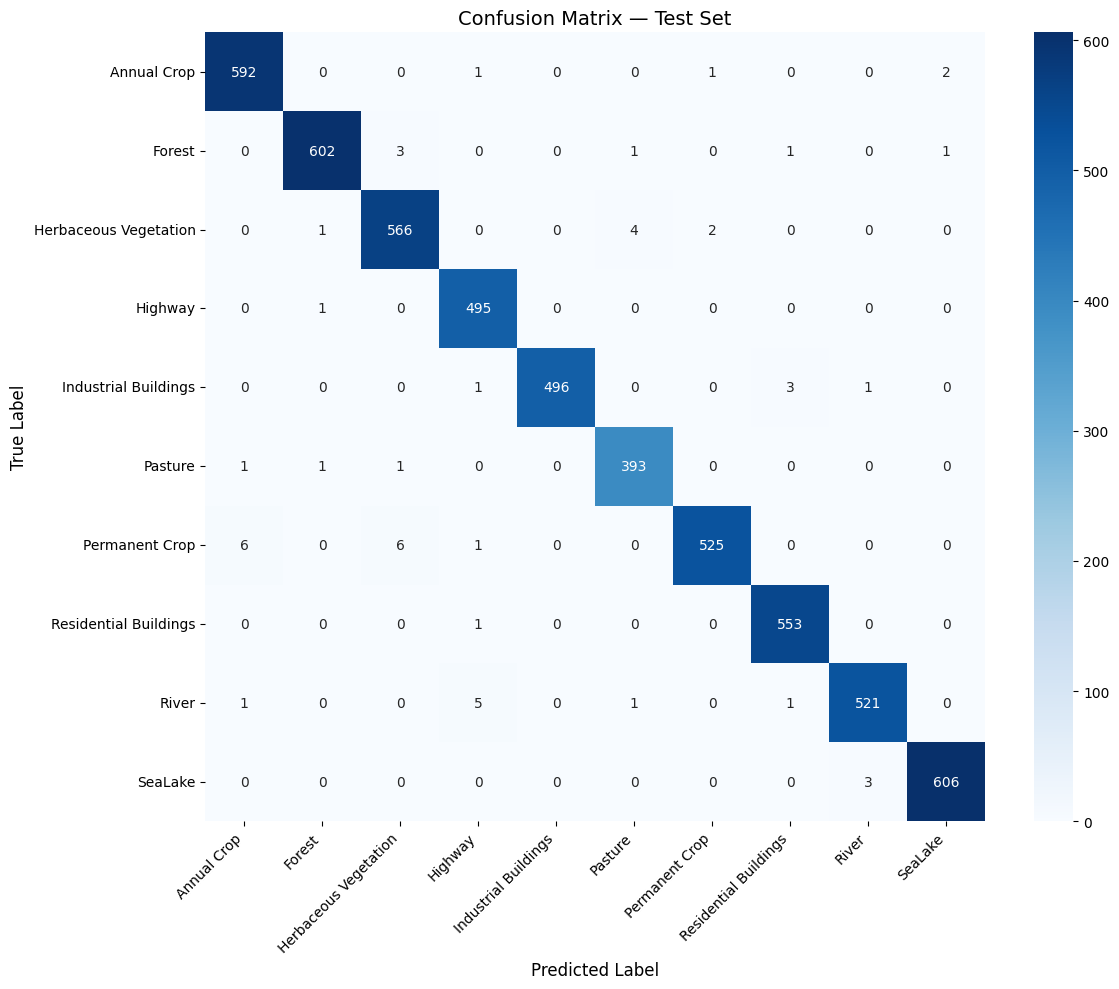

✅ Saved to ../results/confusion_matrix.png


In [5]:
# Generate confusion matrix heatmap
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix — Test Set", fontsize=14)
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../results/confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved to ../results/confusion_matrix.png")

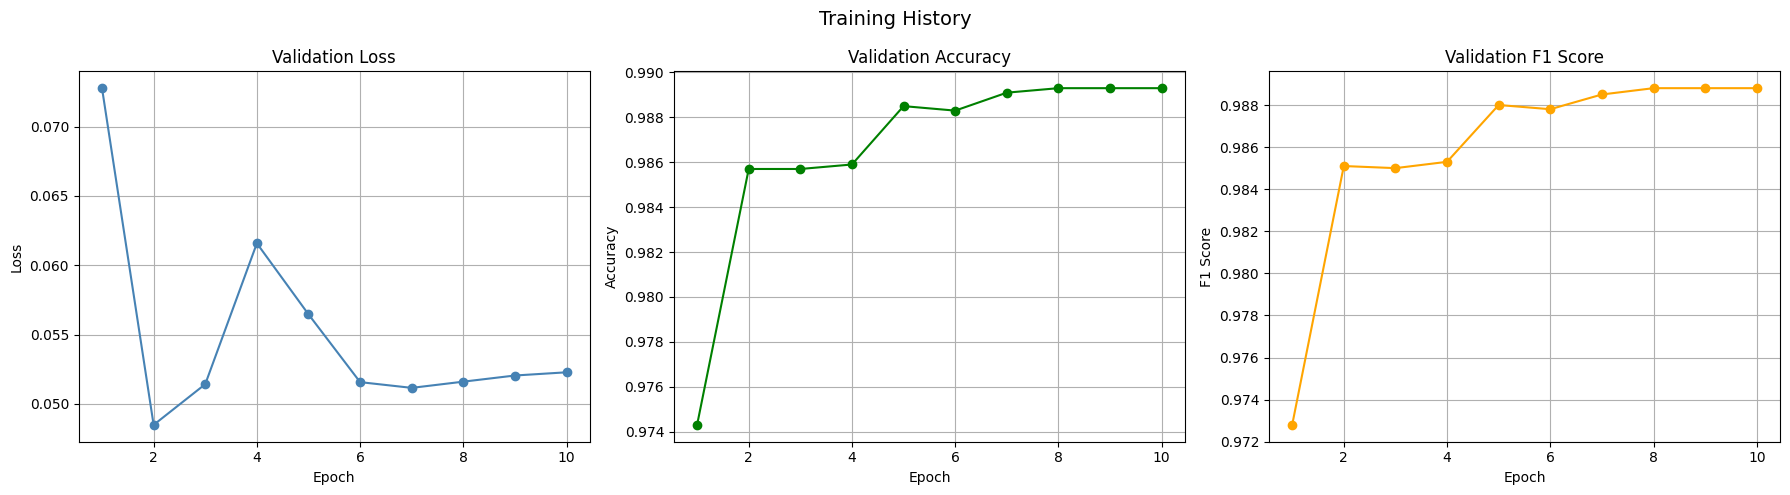

✅ Saved to ../results/training_curves.png


In [6]:
import json

# Load the trainer state to get training history
with open("../models/satellite-vit/checkpoint-5070/trainer_state.json", "r") as f:
    trainer_state = json.load(f)

# Extract loss and accuracy values per epoch
epochs, train_losses, val_losses, accuracies, f1_scores = [], [], [], [], []

for log in trainer_state["log_history"]:
    if "eval_accuracy" in log:
        epochs.append(log["epoch"])
        val_losses.append(log["eval_loss"])
        accuracies.append(log["eval_accuracy"])
        f1_scores.append(log["eval_f1"])
    if "loss" in log and "eval_loss" not in log:
        train_losses.append((log["epoch"], log["loss"]))

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Training History", fontsize=14)

# Plot 1 — Validation Loss
axes[0].plot(epochs, val_losses, marker="o", color="steelblue")
axes[0].set_title("Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True)

# Plot 2 — Accuracy
axes[1].plot(epochs, accuracies, marker="o", color="green")
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True)

# Plot 3 — F1 Score
axes[2].plot(epochs, f1_scores, marker="o", color="orange")
axes[2].set_title("Validation F1 Score")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("F1 Score")
axes[2].grid(True)

plt.tight_layout()
plt.savefig("../results/training_curves.png", dpi=150)
plt.show()
print("✅ Saved to ../results/training_curves.png")

In [8]:
print("=" * 50)
print("EVALUATION COMPLETE")
print("=" * 50)
print(f"  Test Accuracy:      {test_accuracy * 100:.2f}%")
print(f"  Test F1 Score:      {test_f1 * 100:.2f}%")
print(f"  Total test images:  {len(all_preds):,}")
print(f"  Number of classes:  {len(class_names)}")
print()
print("  Best performing class:   SeaLake    (100% F1)")
print("  Weakest performing class: Permanent Crop (98% F1)")
print()
print("  Saved outputs:")
print("    ../results/confusion_matrix.png")
print("    ../results/training_curves.png")
print("=" * 50)

EVALUATION COMPLETE
  Test Accuracy:      99.06%
  Test F1 Score:      99.05%
  Total test images:  5,400
  Number of classes:  10

  Best performing class:   SeaLake    (100% F1)
  Weakest performing class: Permanent Crop (98% F1)

  Saved outputs:
    ../results/confusion_matrix.png
    ../results/training_curves.png
